In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.5 MB/s eta 0:00:00


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="l5uRP6wvNopzE2uYUnuH")
project = rf.workspace("hijrahs-workspace").project("deteksi-pisang-mj1s0")
version = project.version(2)
dataset = version.download("yolo26")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deteksi-Pisang-2 in yolo26:: 100%|██████████| 362/362 [00:00<00:00, 10778.52it/s]


In [3]:
from ultralytics import YOLO

# 1. Inisialisasi model dasar YOLOv26 versi Nano
model = YOLO("yolo26n.pt")

# 2. Memulai proses training
hasil = model.train(
    data=f"{dataset.location}/data.yaml",  # Menunjuk otomatis ke folder dataset yang baru saja diunduh dari Roboflow
    epochs=50,                             # Jumlah putaran latihan. 50-100 biasanya cukup untuk permulaan
    imgsz=320,                             # Resolusi disamakan dengan hasil 'Resize' 320x320 di Roboflow kamu
    optimizer="MuSGD"                      # Memaksa model menggunakan optimizer MuSGD YOLOv26 untuk stabilitas
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Deteksi-Pisang-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=3

In [4]:
metrics = model.val()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 367.4±184.2 MB/s, size: 6.5 KB)
val: Scanning /content/Deteksi-Pisang-2/valid/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 4.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 6.0it/s 0.2s
                   all         15         19      0.836      0.842      0.905      0.662
                pisang         15         19      0.836      0.842      0.905      0.662
Speed: 0.7ms preprocess, 6.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val



image 1/1 /test.jpg: 192x320 5 pisangs, 9.6ms
Speed: 0.8ms preprocess, 9.6ms inference, 0.4ms postprocess per image at shape (1, 3, 192, 320)


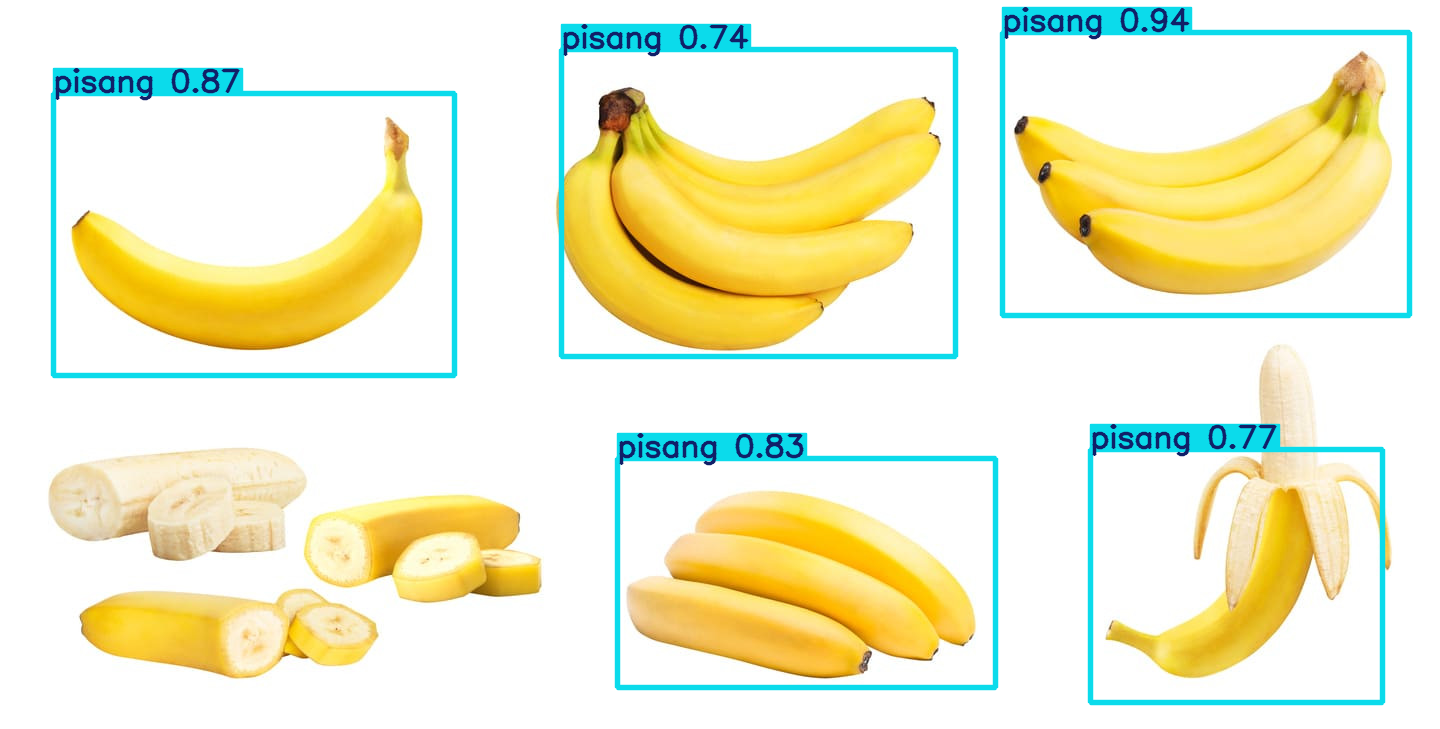

In [9]:
# Tambahkan garis miring '/' di depan nama file untuk menunjuk ke folder root
hasil_prediksi = model("/test.jpg")

# Ingat! Buka bungkus list-nya dengan menambahkan indeks
hasil_prediksi[0].show()

In [10]:
!find /content -name "*.pt"


/content/runs/detect/train/weights/last.pt
/content/runs/detect/train/weights/best.pt
/content/yolo26n.pt


In [11]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
model.export(format="onnx")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 237ms
Prepared 4 packages in 6.75s
Installed 4 packages in 269ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 8.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 9.7s, saved as 'runs/detect/train/weights/best.onnx' (9.2 MB)

Export complete (10.1s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=320 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=320 data=/content/Deteksi-Pisang-2/data.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.onnx'